In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../../')

In [2]:
from pathlib import Path
import math
import time
import random
import numbers
import datetime
from functools import partial

import torch
from torch.nn.modules.utils import _pair

from torchvision import transforms

import numpy as np
from PIL import Image

%load_ext autoreload
%autoreload 2

from computer_vision.video_mae.finetune_parameter_parser import parser
from computer_vision.video_mae.dataset.datasets import VideoClsDataset
from computer_vision.video_mae.dataset.video_transforms import _pil_interp

In [3]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
train_annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask/trainlist01.txt'
val_annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask/vallist01.txt'

mini_train=False
if not mini_train:
    pretrain_path=Path('D:/results/ucf101/video_mae/train/checkpoints/last.pth') 
    output_dirpath=Path('D:/results/ucf101/video_mae/finetune') 
    arguments= f"""--data_root {root} --train_data_path {train_annotation_path} --val_data_path {val_annotation_path} 
    --output_dir {output_dirpath} --finetune {pretrain_path} 
    --data_set UCF101 --nb_classes 101  --batch_size 3 --input_size 224
    --short_side_size 224 --num_frames 16 --sampling_rate 4 --num_sample 2 --num_workers 0 --opt adamw
    --lr 1e-3 --drop_path 0.3 --clip_grad 5.0 --layer_decay 0.9 --opt_betas 0.9 0.999 --weight_decay 0.1
    --test_num_segment 5 --test_num_crop 3 --dist_eval
    --warmup_epochs 5 --epochs 35  --print_freq 20 --device cpu --time 12 --resume
    """ # --use-cutmix-mixup
else:
    pretrain_path=Path('D:/results/ucf101/video_mae/mini_train/checkpoints/last.pth') 
    output_dirpath=Path('D:/results/ucf101/video_mae/mini_finetune') 
    arguments= f"""--data_root {root} --train_data_path {train_annotation_path} --val_data_path {val_annotation_path} 
    --output_dir {output_dirpath}  --finetune {pretrain_path} 
    --data_set UCF101 --nb_classes 101  --batch_size 3 --input_size 224
    --short_side_size 224 --num_frames 16 --sampling_rate 4 --num_sample 2 --num_workers 0 --opt adamw
    --lr 1e-3 --drop_path 0.3 --clip_grad 5.0 --layer_decay 0.9 --opt_betas 0.9 0.999 --weight_decay 0.1
    --test_num_segment 5 --test_num_crop 3 --dist_eval 
    --warmup_epochs 5 --print_freq 20 --epochs 35  --device cpu --resume
    --n_steps 12 --n_epochs 2 --time 0.5
    """ # --use-cutmix-mixup --time 18 --resume

known_args, _=parser.parse_known_args(args=arguments.split())
if known_args.enable_deepspeed:
    parser=deepspeed.add_config_arguments(parser)
    ds_init=deepspeed.initialize
else: ds_init=None
args=parser.parse_args(arguments.split())


In [4]:
dataset_train=VideoClsDataset(data_root=args.data_root, anno_path=args.train_data_path, mode='train', clip_len=args.num_frames, 
                        frame_sample_rate=args.sampling_rate, num_segment=1, test_num_segment=args.test_num_segment,
                        test_num_crop=args.test_num_crop, num_crop=1, keep_aspect_ratio=True, crop_size=args.input_size,
                        short_side_size=args.short_side_size, new_height=256, new_width=320, args=args)
args.nb_classes=101

# dataset_val=VideoClsDataset(data_root=args.data_root, anno_path=args.val_data_path, mode='validation', clip_len=args.num_frames, 
#                         frame_sample_rate=args.sampling_rate, num_segment=1, test_num_segment=args.test_num_segment,
#                         test_num_crop=args.test_num_crop, num_crop=1, keep_aspect_ratio=True, crop_size=args.input_size,
#                         short_side_size=args.short_side_size, new_height=256, new_width=320, args=args)

# dataset_test=VideoClsDataset(data_root=args.data_root, anno_path=args.val_data_path, mode='test', clip_len=args.num_frames, 
#                         frame_sample_rate=args.sampling_rate, num_segment=1, test_num_segment=args.test_num_segment,
#                         test_num_crop=args.test_num_crop, num_crop=3, keep_aspect_ratio=True, crop_size=args.input_size,
#                         short_side_size=args.short_side_size, new_height=256, new_width=320, args=args)

In [5]:
index=90
# def __getitem__(self, index):
# if self.mode=='train':

args=dataset_train.args
scale_t=1
sample=dataset_train.dataset_samples[index]
print(f"{sample=}, {os.path.isfile(sample)=}")
# (T,H,W,C)
buffer=dataset_train.load_video(sample, sample_rate_scale=scale_t)
print(f'{buffer.shape=}, {buffer.dtype=}')#, {len(self)}')
if len(buffer)==0:
    while len(buffer)==0:
        warnings.warn(f"Video {sample} was not loaded correctly during training")
        index=np.random.randint(len(dataset_train))
        sample=dataset_train.dataset_samples[index]
        buffer=dataset_train.load_video(sample, sample_rate_scale=scale_t)
if args.num_sample>1:
    frame_list, label_list,index_list=[],[],[]
    for _ in range(args.num_sample):
        #new_frames=self._aug_frame(buffer, args)
        break

sample='D:\\data\\UCF101\\UCF-101\\ApplyEyeMakeup/v_ApplyEyeMakeup_g24_c04.avi', os.path.isfile(sample)=True
buffer.shape=(16, 240, 320, 3), buffer.dtype=dtype('uint8')


In [6]:
buffer.shape, type(buffer), buffer.transpose(0,3,1,2).shape, buffer.dtype

((16, 240, 320, 3), numpy.ndarray, (16, 3, 240, 320), dtype('uint8'))

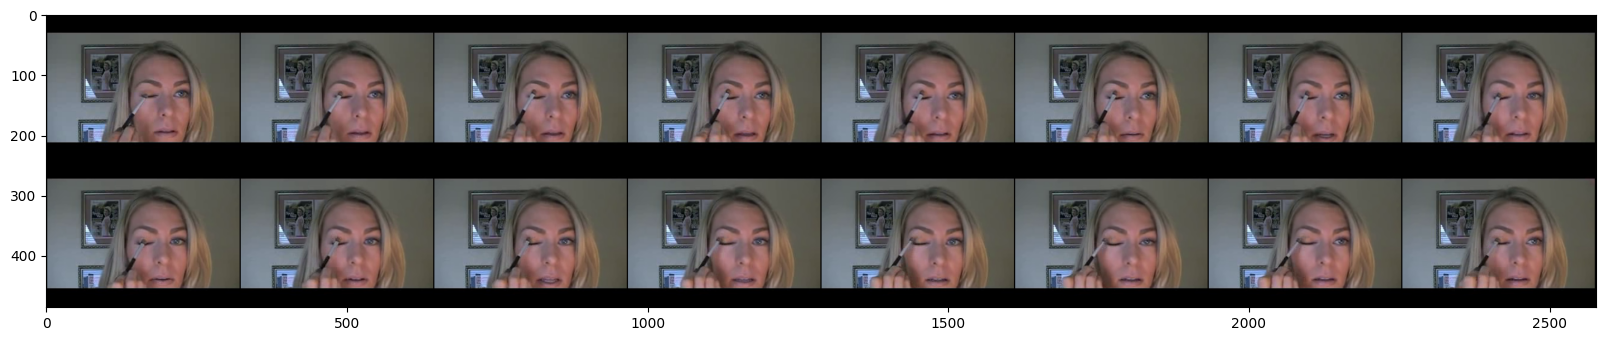

In [7]:
plt.figure(figsize=(20,20))
plt.imshow(make_grid(torch.from_numpy(buffer.transpose(0,3,1,2))).permute(1,2,0))

In [8]:
from computer_vision.video_mae.dataset.video_transforms import create_random_augment, random_short_side_scale_jitter, random_crop, \
_get_param_spatial_crop, random_resized_crop, random_resized_crop_with_shift, horizontal_flip, crop_boxes, uniform_crop
from computer_vision.video_mae.dataset.pretrained_datasets import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from computer_vision.video_mae.dataset.datasets import tensor_normalize, spatial_sampling

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].


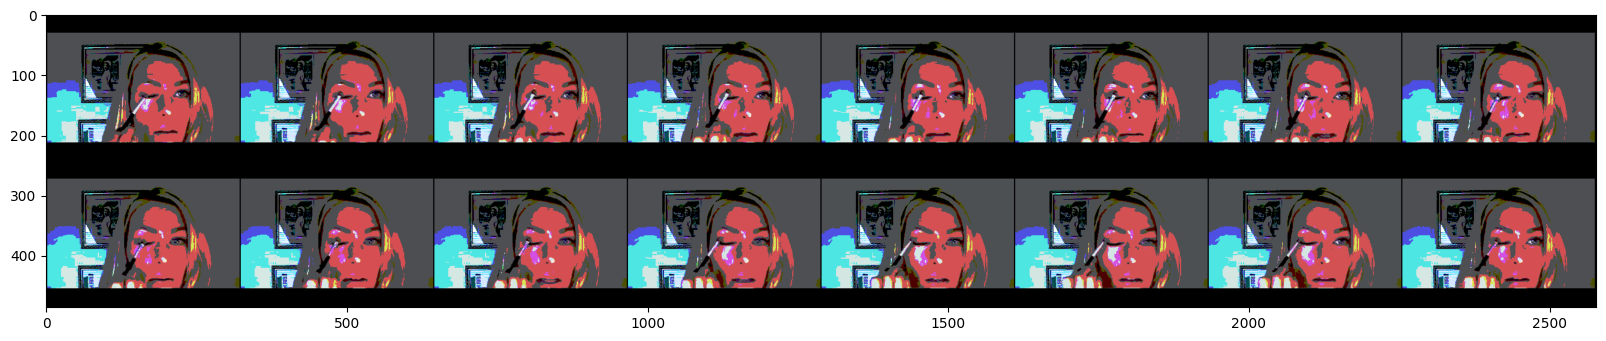

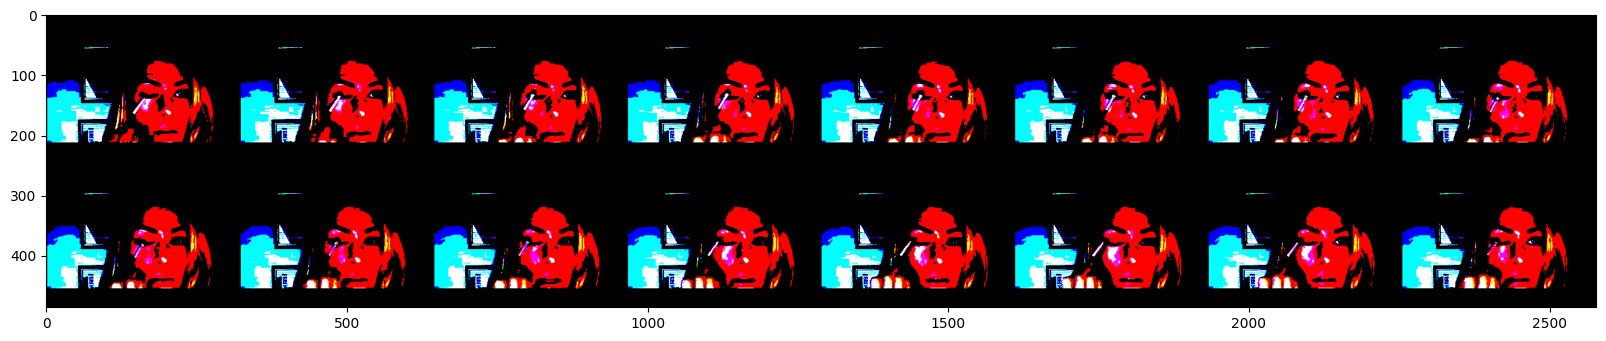

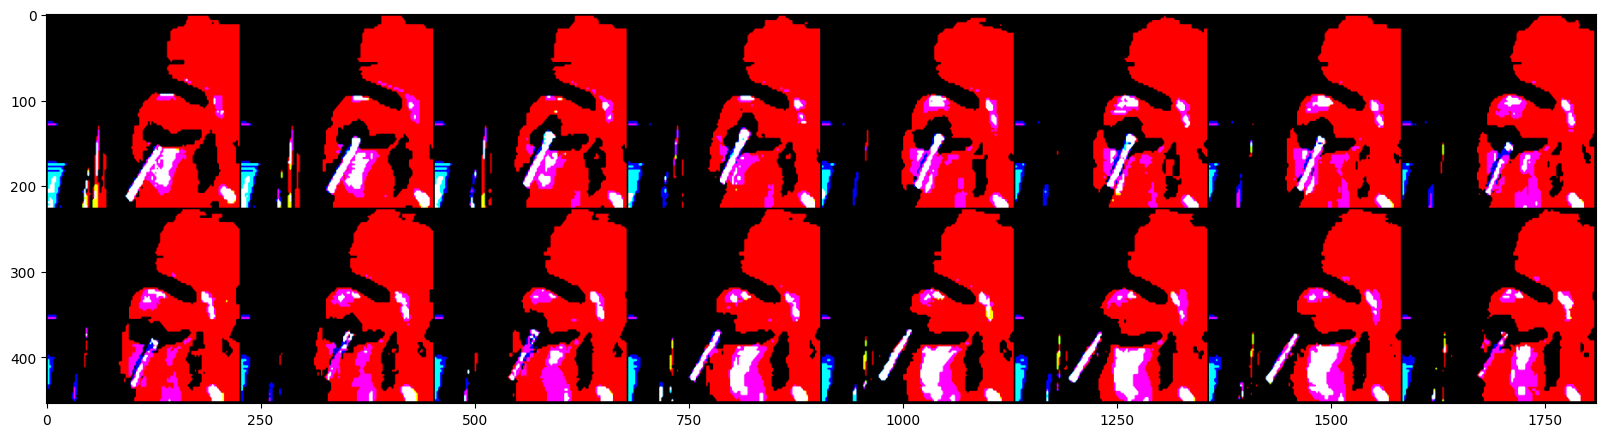

In [9]:
#def _aug_frame(self, buffer, args):

buffer=[transforms.ToPILImage()(frame) for frame in buffer] # list of (H,W,C)

aug_transform=create_random_augment(input_size=(dataset_train.crop_size, dataset_train.crop_size),
                                    auto_augment=args.aa, interpolation=args.train_interpolation)
buffer=aug_transform(buffer) # PIL.Image with image.size (W,H) and np.array(x).shape of (H,W,d)
buffer=[transforms.ToTensor()(img) for img in buffer]
buffer=torch.stack(buffer) # (T,C,H,W)

plt.figure(figsize=(20,20))
plt.imshow(make_grid(buffer).permute(1,2,0))

buffer=tensor_normalize(buffer, mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD) # (T,C,H,W)

plt.figure(figsize=(20,20))
plt.imshow(make_grid(buffer).permute(1,2,0))

# buffer=buffer.permute(1,0,2,3).contiguous() # (C,T,H,W)
# Perform data augmentation
scale, aspect_ratio=([0.08,1.0],[0.75,1.3333])
buffer=spatial_sampling(buffer, spatial_idx=-1, min_scale=256, max_scale=320, crop_size=dataset_train.crop_size, 
                        random_horizontal_flip=True, inverse_uniform_sampling=False, aspect_ratio=aspect_ratio, 
                        scale=scale, motion_shift=False)

plt.figure(figsize=(20,20))
plt.imshow(make_grid(buffer).permute(1,2,0))

1.2787593157922534

In [16]:
math.exp(np.random.uniform(*log_ratio))

1.0780748591496783

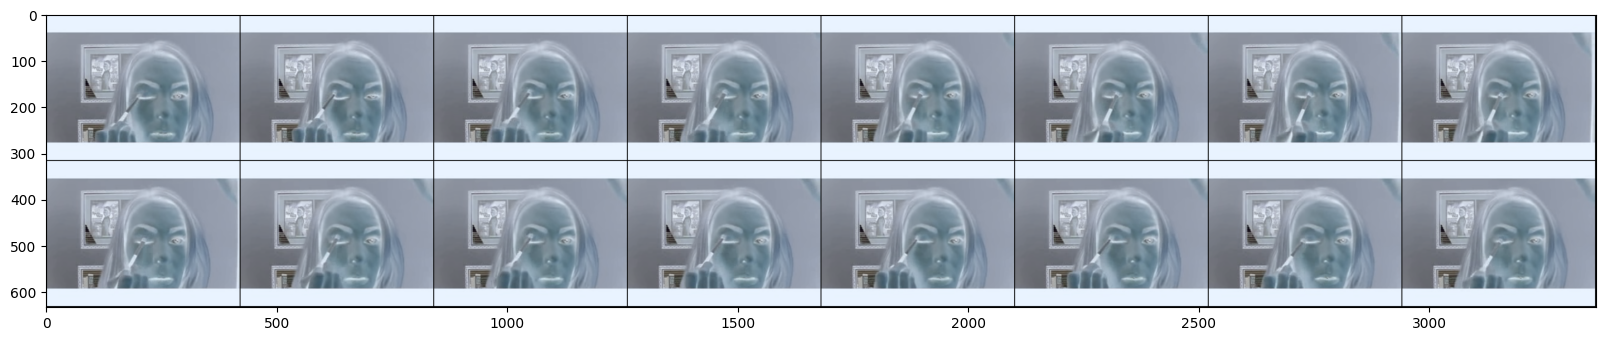

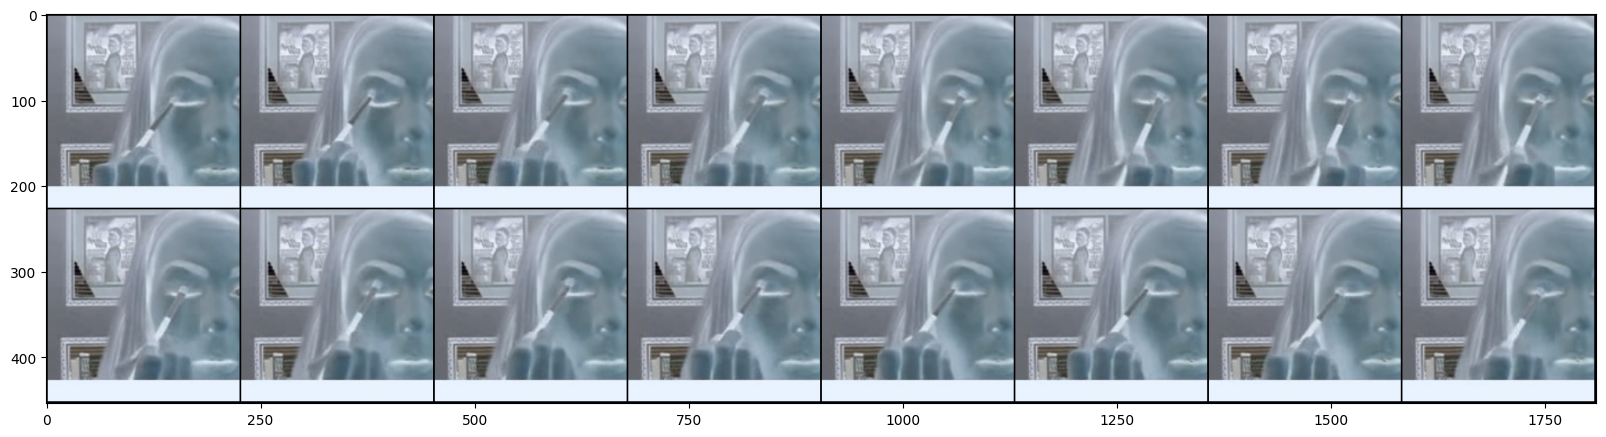

In [12]:
outs,_=random_short_side_scale_jitter(images=frames.clone(), min_size=min_scale, max_size=max_scale, boxes=None, 
                                                inverse_uniform_sampling=inverse_uniform_sampling)
plt.figure(figsize=(20,20))
plt.imshow(make_grid(outs,normalize=True).permute(1,2,0))

outs, _=random_crop(outs, crop_size)
plt.figure(figsize=(20,20))
plt.imshow(make_grid(outs,normalize=True).permute(1,2,0))
